In [1]:
# @title 1. Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style="ticks")
print("Библиотеки импортированы")

Библиотеки импортированы


In [3]:
# @title 2. Загрузка датасета Titanic
# Загружаем данные с локального файла или из URL
import urllib.request
import os

# Скачиваем данные с GitHub (альтернативный источник)
url_train = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

try:
    urllib.request.urlretrieve(url_train, "titanic.csv")
    df = pd.read_csv("titanic.csv")
    print("Датасет Titanic загружен успешно!")
except Exception as e:
    print(f"Ошибка загрузки: {e}")

print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

Датасет Titanic загружен успешно!
Размер датасета: (891, 12)
Колонки: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
# @title 3. Первичный анализ данных
print("ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print(f"Размер датасета: {df.shape}")

print("\nПервые 5 строк:")
display(df.head())

print("\nТипы данных:")
print(df.dtypes)

print("\nСтатистика по числовым признакам:")
display(df.describe())

print("\nПропущенные значения:")
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
if len(null_counts) > 0:
    for col, count in null_counts.items():
        print(f"  {col}: {count} пропусков ({count/len(df)*100:.2f}%)")
else:
    print("  Пропусков нет")

# Целевая переменная
print("\nЦелевая переменная - Survived (выживание):")
print(df['Survived'].value_counts())
print(f"\n0 (погиб): {sum(df['Survived']==0)} ({sum(df['Survived']==0)/len(df)*100:.2f}%)")
print(f"1 (выжил): {sum(df['Survived']==1)} ({sum(df['Survived']==1)/len(df)*100:.2f}%)")

ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
Размер датасета: (891, 12)

Первые 5 строк:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Статистика по числовым признакам:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Пропущенные значения:
  Age: 177 пропусков (19.87%)
  Cabin: 687 пропусков (77.10%)
  Embarked: 2 пропусков (0.22%)

Целевая переменная - Survived (выживание):
Survived
0    549
1    342
Name: count, dtype: int64

0 (погиб): 549 (61.62%)
1 (выжил): 342 (38.38%)


АНАЛИЗ ПРИЗНАКОВ


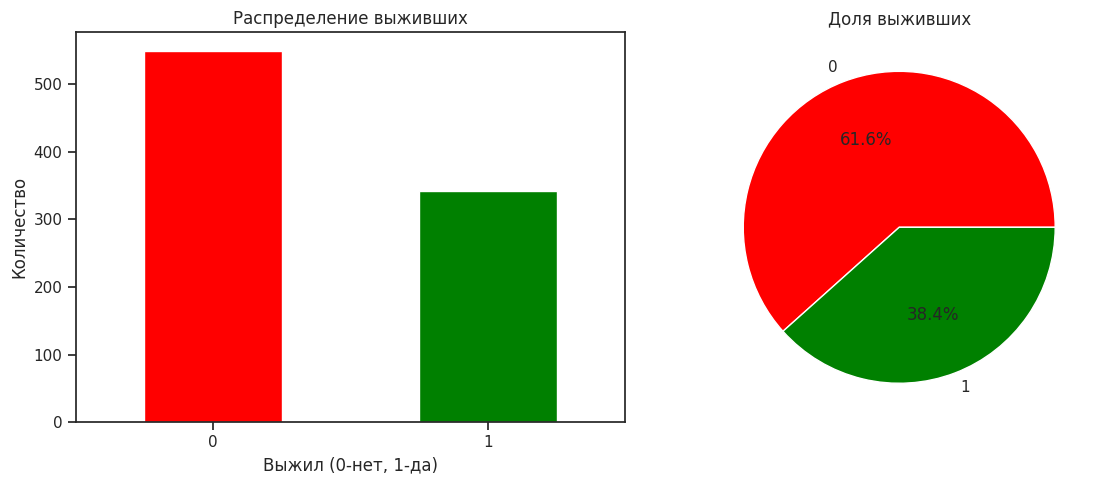

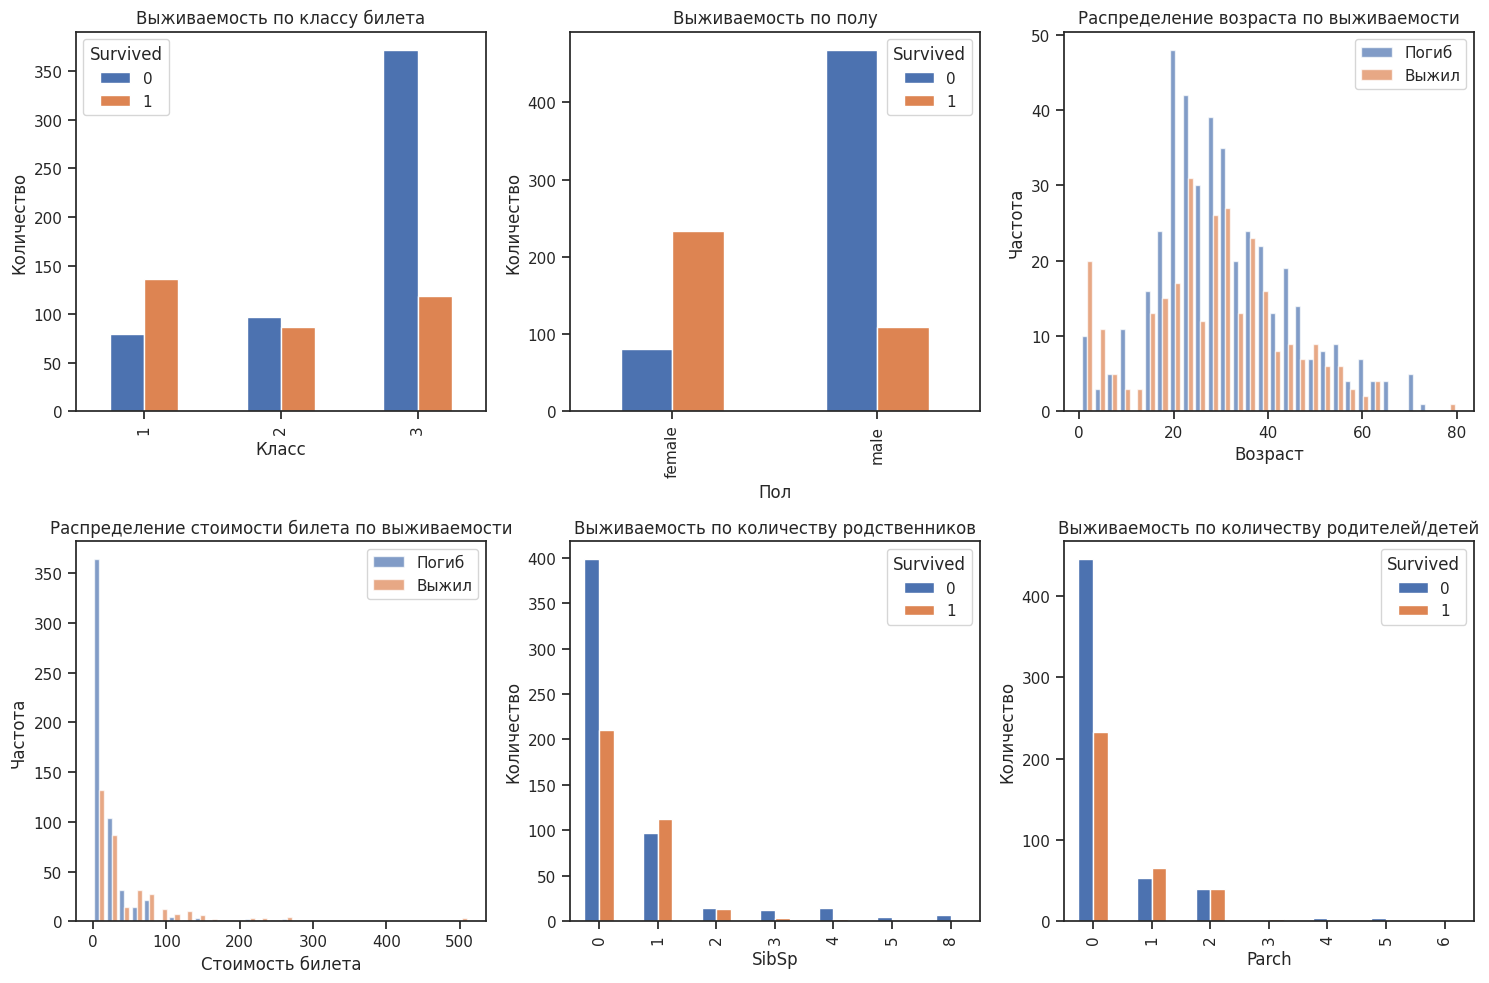

In [6]:
# @title 4. Анализ признаков
print("АНАЛИЗ ПРИЗНАКОВ")

# Визуализация распределения целевой переменной
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Распределение выживших')
plt.xlabel('Выжил (0-нет, 1-да)')
plt.ylabel('Количество')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Доля выживших')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Анализ влияния признаков на выживаемость
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Выживаемость по классу билета')
axes[0, 0].set_xlabel('Класс')
axes[0, 0].set_ylabel('Количество')

pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Выживаемость по полу')
axes[0, 1].set_xlabel('Пол')
axes[0, 1].set_ylabel('Количество')

axes[0, 2].hist([df[df['Survived']==0]['Age'].dropna(),
                  df[df['Survived']==1]['Age'].dropna()],
                 bins=30, label=['Погиб', 'Выжил'], alpha=0.7)
axes[0, 2].set_title('Распределение возраста по выживаемости')
axes[0, 2].set_xlabel('Возраст')
axes[0, 2].set_ylabel('Частота')
axes[0, 2].legend()

axes[1, 0].hist([df[df['Survived']==0]['Fare'].dropna(),
                  df[df['Survived']==1]['Fare'].dropna()],
                 bins=30, label=['Погиб', 'Выжил'], alpha=0.7)
axes[1, 0].set_title('Распределение стоимости билета по выживаемости')
axes[1, 0].set_xlabel('Стоимость билета')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()

pd.crosstab(df['SibSp'], df['Survived']).plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Выживаемость по количеству родственников')
axes[1, 1].set_xlabel('SibSp')
axes[1, 1].set_ylabel('Количество')

pd.crosstab(df['Parch'], df['Survived']).plot(kind='bar', ax=axes[1, 2])
axes[1, 2].set_title('Выживаемость по количеству родителей/детей')
axes[1, 2].set_xlabel('Parch')
axes[1, 2].set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [7]:
# @title 5. Обработка пропусков
df_clean = df.copy()

print("ОБРАБОТКА ПРОПУСКОВ")

# Пропуски в Age - заполняем медианой
if 'Age' in df.columns and df['Age'].isnull().sum() > 0:
    null_count = df['Age'].isnull().sum()
    print(f"\nКолонка Age: {null_count} пропусков ({null_count/len(df)*100:.2f}%)")
    median_age = df['Age'].median()
    print(f"Медиана возраста: {median_age:.1f}")
    imp_median = SimpleImputer(strategy='median')
    df_clean['Age'] = imp_median.fit_transform(df_clean[['Age']])
    print(f"Заполнено медианой")

# Пропуски в Fare - заполняем медианой
if 'Fare' in df.columns and df['Fare'].isnull().sum() > 0:
    null_count = df['Fare'].isnull().sum()
    print(f"\nКолонка Fare: {null_count} пропусков ({null_count/len(df)*100:.2f}%)")
    median_fare = df['Fare'].median()
    print(f"Медиана стоимости: {median_fare:.2f}")
    imp_median = SimpleImputer(strategy='median')
    df_clean['Fare'] = imp_median.fit_transform(df_clean[['Fare']])
    print(f"Заполнено медианой")

# Пропуски в Embarked - заполняем модой
if 'Embarked' in df.columns and df['Embarked'].isnull().sum() > 0:
    null_count = df['Embarked'].isnull().sum()
    print(f"\nКолонка Embarked: {null_count} пропусков ({null_count/len(df)*100:.2f}%)")
    mode_embarked = df['Embarked'].mode()[0]
    print(f"Мода: {mode_embarked}")
    imp_mode = SimpleImputer(strategy='most_frequent')
    df_clean['Embarked'] = imp_mode.fit_transform(df_clean[['Embarked']]).ravel()
    print(f"Заполнено модой")

# Удаляем колонки, которые не будем использовать
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
for col in cols_to_drop:
    if col in df_clean.columns:
        df_clean = df_clean.drop(col, axis=1)
        print(f"Удалена колонка: {col}")

print(f"\nРазмер датасета после очистки: {df_clean.shape}")
print(f"Пропусков после обработки: {df_clean.isnull().sum().sum()}")

ОБРАБОТКА ПРОПУСКОВ

Колонка Age: 177 пропусков (19.87%)
Медиана возраста: 28.0
Заполнено медианой

Колонка Embarked: 2 пропусков (0.22%)
Мода: S
Заполнено модой
Удалена колонка: PassengerId
Удалена колонка: Name
Удалена колонка: Ticket
Удалена колонка: Cabin

Размер датасета после очистки: (891, 8)
Пропусков после обработки: 0


In [8]:
# @title 6. Кодирование категориальных признаков
print("КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

# Определяем категориальные признаки
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки: {cat_cols}")

df_encoded = df_clean.copy()

for col in cat_cols:
    print(f"\nКолонка: {col}")
    print(f"Уникальные значения: {df_encoded[col].unique()}")

    # Для бинарных признаков используем Label Encoding
    if df_encoded[col].nunique() == 2:
        le = LabelEncoder()
        df_encoded[f"{col}_code"] = le.fit_transform(df_encoded[col].astype(str))
        print(f"  Бинарный признак -> Label Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
        df_encoded = df_encoded.drop(col, axis=1)

    # Для признаков с 3-5 категориями используем One-Hot Encoding
    elif df_encoded[col].nunique() <= 5:
        dummies = pd.get_dummies(df_encoded[col], prefix=col, dtype=int)
        print(f"  Категориальный -> One-Hot Encoding: создано {dummies.shape[1]} признаков")
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        df_encoded = df_encoded.drop(col, axis=1)

print(f"\nРазмер датасета после кодирования: {df_encoded.shape}")

КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
Категориальные признаки: ['Sex', 'Embarked']

Колонка: Sex
Уникальные значения: ['male' 'female']
  Бинарный признак -> Label Encoding: {'female': np.int64(0), 'male': np.int64(1)}

Колонка: Embarked
Уникальные значения: ['S' 'C' 'Q']
  Категориальный -> One-Hot Encoding: создано 3 признаков

Размер датасета после кодирования: (891, 10)


In [9]:
# @title 7. Подготовка признаков и целевой переменной
# Целевая переменная
y = df_encoded['Survived'].values

# Признаки (все кроме Survived)
feature_cols = [col for col in df_encoded.columns if col != 'Survived']
X = df_encoded[feature_cols].values

print(f"Размер матрицы признаков X: {X.shape}")
print(f"Количество признаков: {len(feature_cols)}")
print(f"Первые 10 признаков: {feature_cols[:10]}")

print(f"\nРазмер целевой переменной y: {y.shape}")
print(f"Распределение классов:")
print(f"  0 (погиб): {sum(y==0)} ({sum(y==0)/len(y)*100:.2f}%)")
print(f"  1 (выжил): {sum(y==1)} ({sum(y==1)/len(y)*100:.2f}%)")

Размер матрицы признаков X: (891, 9)
Количество признаков: 9
Первые 10 признаков: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_code', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

Размер целевой переменной y: (891,)
Распределение классов:
  0 (погиб): 549 (61.62%)
  1 (выжил): 342 (38.38%)


Статистика ДО масштабирования (первые 5 признаков):
             0          1         2         3           4
mean  2.308642  29.361582  0.523008  0.381594   32.204208
std   0.836071  13.019697  1.102743  0.806057   49.693429
min   1.000000   0.420000  0.000000  0.000000    0.000000
max   3.000000  80.000000  8.000000  6.000000  512.329200

Статистика ПОСЛЕ масштабирования (первые 5 признаков):
                 0             1             2             3             4
mean -8.772133e-17  2.272780e-16  4.386066e-17  5.382900e-17  3.987333e-18
std   1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00
min  -1.566107e+00 -2.224156e+00 -4.745452e-01 -4.736736e-01 -6.484217e-01
max   8.273772e-01  3.891554e+00  6.784163e+00  6.974147e+00  9.667167e+00


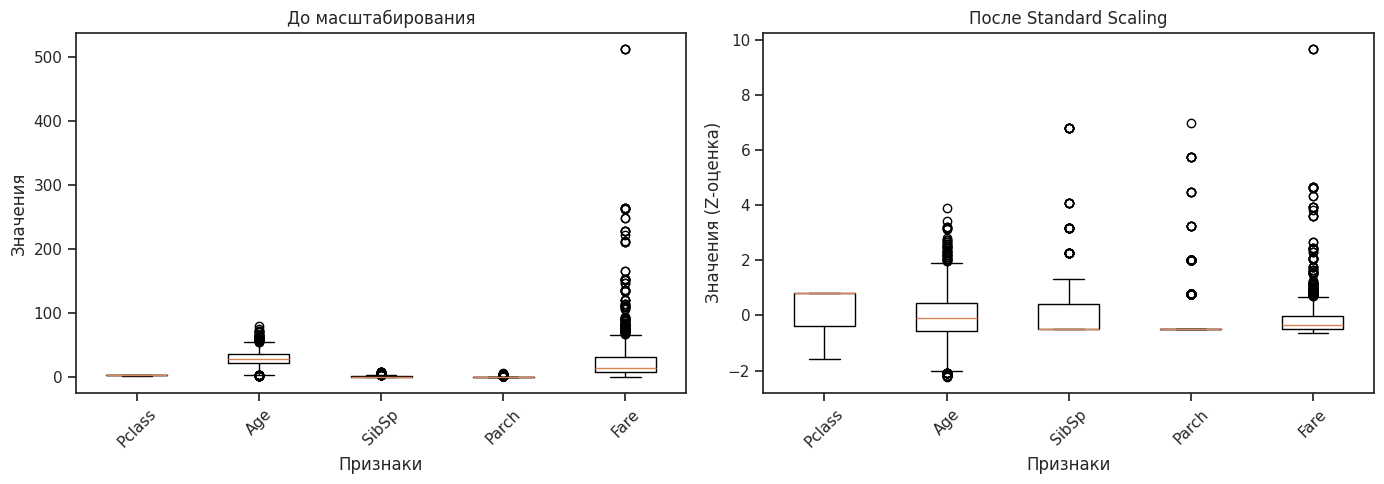

Box plot показывает, что после масштабирования все признаки имеют сравнимый масштаб.


In [10]:
# @title 8. Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Статистика ДО масштабирования (первые 5 признаков):")
print(pd.DataFrame(X[:, :5]).describe().loc[['mean', 'std', 'min', 'max']])

print("\nСтатистика ПОСЛЕ масштабирования (первые 5 признаков):")
print(pd.DataFrame(X_scaled[:, :5]).describe().loc[['mean', 'std', 'min', 'max']])

# Визуализация эффекта масштабирования
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(X[:, :5])
axes[0].set_title('До масштабирования')
axes[0].set_xlabel('Признаки')
axes[0].set_ylabel('Значения')
axes[0].set_xticklabels(feature_cols[:5], rotation=45)

axes[1].boxplot(X_scaled[:, :5])
axes[1].set_title('После Standard Scaling')
axes[1].set_xlabel('Признаки')
axes[1].set_ylabel('Значения (Z-оценка)')
axes[1].set_xticklabels(feature_cols[:5], rotation=45)

plt.tight_layout()
plt.show()
print("Box plot показывает, что после масштабирования все признаки имеют сравнимый масштаб.")

In [11]:
# @title 9. Разделение на обучающую и тестовую выборки
# Разделяем данные: 70% обучающая, 30% тестовая
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} строк ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} строк ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nРаспределение классов в обучающей выборке:")
print(f"  0: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.2f}%)")
print(f"  1: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.2f}%)")

print(f"\nРаспределение классов в тестовой выборке:")
print(f"  0: {sum(y_test==0)} ({sum(y_test==0)/len(y_test)*100:.2f}%)")
print(f"  1: {sum(y_test==1)} ({sum(y_test==1)/len(y_test)*100:.2f}%)")

Обучающая выборка: 623 строк (69.9%)
Тестовая выборка: 268 строк (30.1%)

Распределение классов в обучающей выборке:
  0: 384 (61.64%)
  1: 239 (38.36%)

Распределение классов в тестовой выборке:
  0: 165 (61.57%)
  1: 103 (38.43%)


In [13]:
# @title 10. Обучение моделей

print("\n1. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print("Модель обучена")

print("\n2. SVM (Support Vector Machine)")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print("Модель обучена")

print("\n3. ДЕРЕВО РЕШЕНИЙ")
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
print("Модель обучена")


1. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
Модель обучена

2. SVM (Support Vector Machine)
Модель обучена

3. ДЕРЕВО РЕШЕНИЙ
Модель обучена


In [14]:
# @title 11. Оценка качества моделей
models = {
    'Logistic Regression': lr_model,
    'SVM': svm_model,
    'Decision Tree': dt_model
}

results = []

for name, model in models.items():
    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results.append({
        'Модель': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

results_df = pd.DataFrame(results)
print("\n\nСРАВНИТЕЛЬНАЯ ТАБЛИЦА:")
display(results_df.round(4))


Logistic Regression:
  Accuracy:  0.7985
  Precision: 0.7426
  Recall:    0.7282
  F1-score:  0.7353
  ROC-AUC:   0.8486

SVM:
  Accuracy:  0.8097
  Precision: 0.7955
  Recall:    0.6796
  F1-score:  0.7330
  ROC-AUC:   0.8475

Decision Tree:
  Accuracy:  0.7873
  Precision: 0.8026
  Recall:    0.5922
  F1-score:  0.6816
  ROC-AUC:   0.8482


СРАВНИТЕЛЬНАЯ ТАБЛИЦА:


,Модель,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7985,0.7426,0.7282,0.7353,0.8486
1,SVM,0.8097,0.7955,0.6796,0.7330,0.8475
2,Decision Tree,0.7873,0.8026,0.5922,0.6816,0.8482


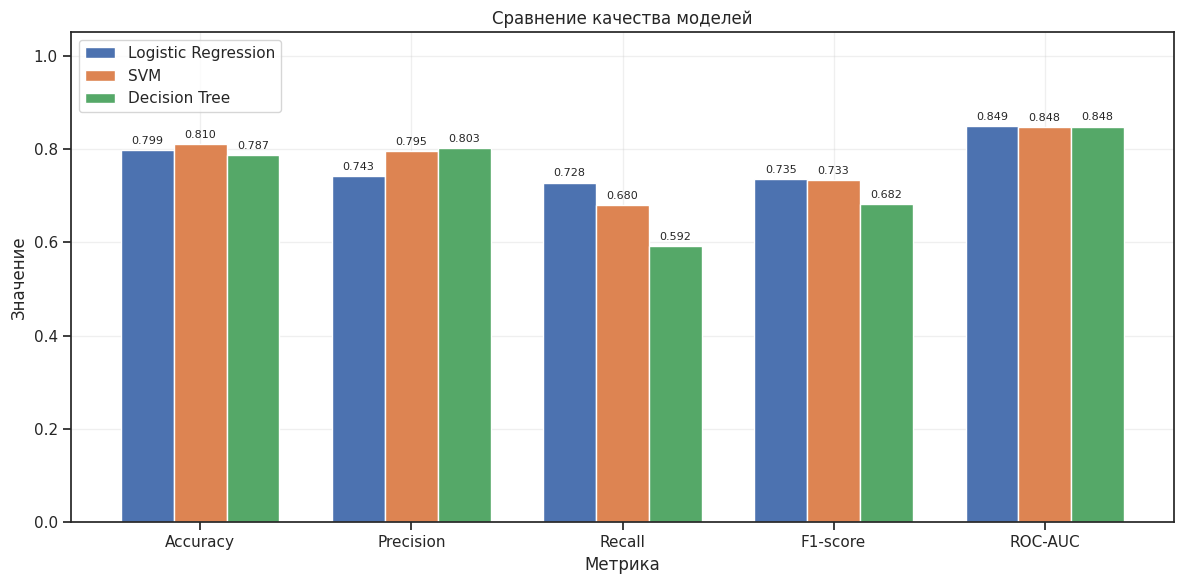

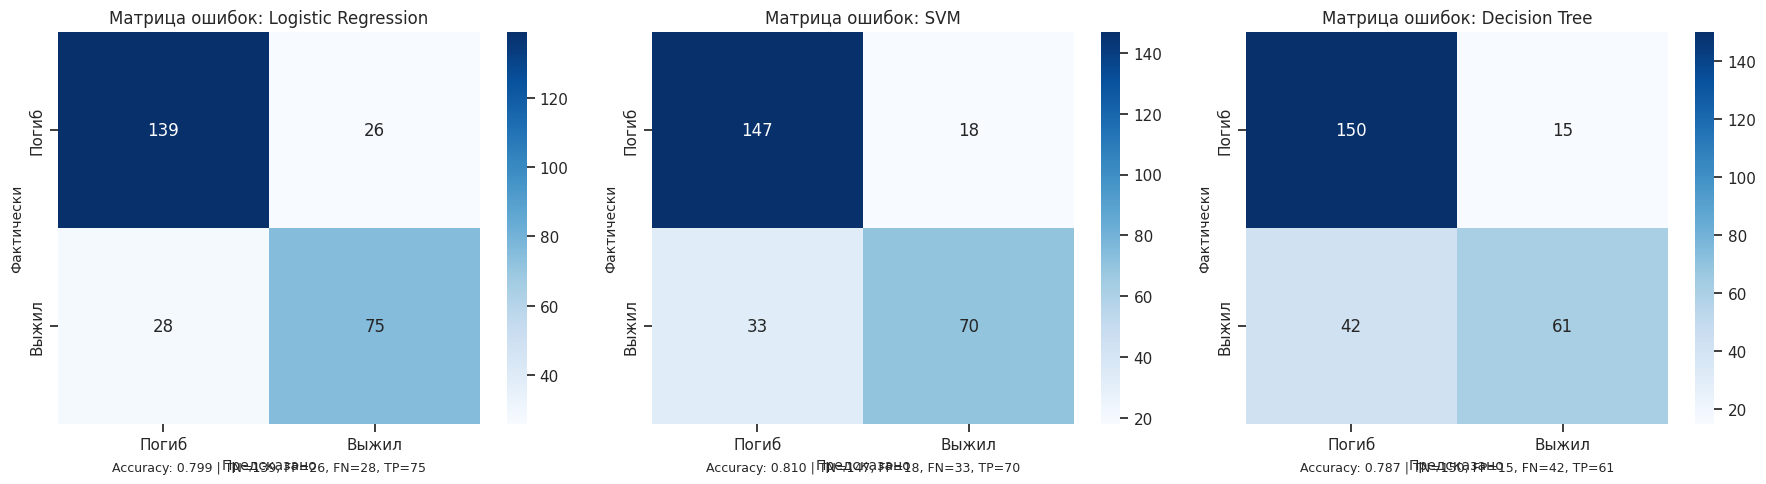

In [25]:
# @title 12. Визуализация сравнения моделей

# График сравнения метрик (только один график)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))

model_values = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    values = [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred_proba)
    ]
    model_values.append(values)

    bars = plt.bar(x + len(model_values)*width - width, values, width, label=name)

plt.xlabel('Метрика')
plt.ylabel('Значение')
plt.title('Сравнение качества моделей')
plt.xticks(x + width, metrics)
plt.legend()
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for i, values in enumerate(model_values):
    for j, (bar, val) in enumerate(zip(plt.gca().containers[i], values)):
        plt.annotate(f'{val:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, val),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Матрицы ошибок (три графика в одной строке)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Погиб', 'Выжил'],
                yticklabels=['Погиб', 'Выжил'])
    axes[i].set_title(f'Матрица ошибок: {name}', fontsize=12)
    axes[i].set_xlabel('Предсказано', fontsize=10)
    axes[i].set_ylabel('Фактически', fontsize=10)

    # Добавляем информацию под графиком
    axes[i].text(0.5, -0.12, f'Accuracy: {acc:.3f} | TN={tn}, FP={fp}, FN={fn}, TP={tp}',
                 transform=axes[i].transAxes, ha='center', fontsize=9)

plt.tight_layout()
plt.show()


Ранжирование признаков по важности:
  1. Sex_code: 0.5440
  2. Pclass: 0.1571
  3. Fare: 0.1500
  4. Age: 0.1328
  5. SibSp: 0.0111
  6. Embarked_C: 0.0043
  7. Parch: 0.0008
  8. Embarked_S: 0.0000
  9. Embarked_Q: 0.0000


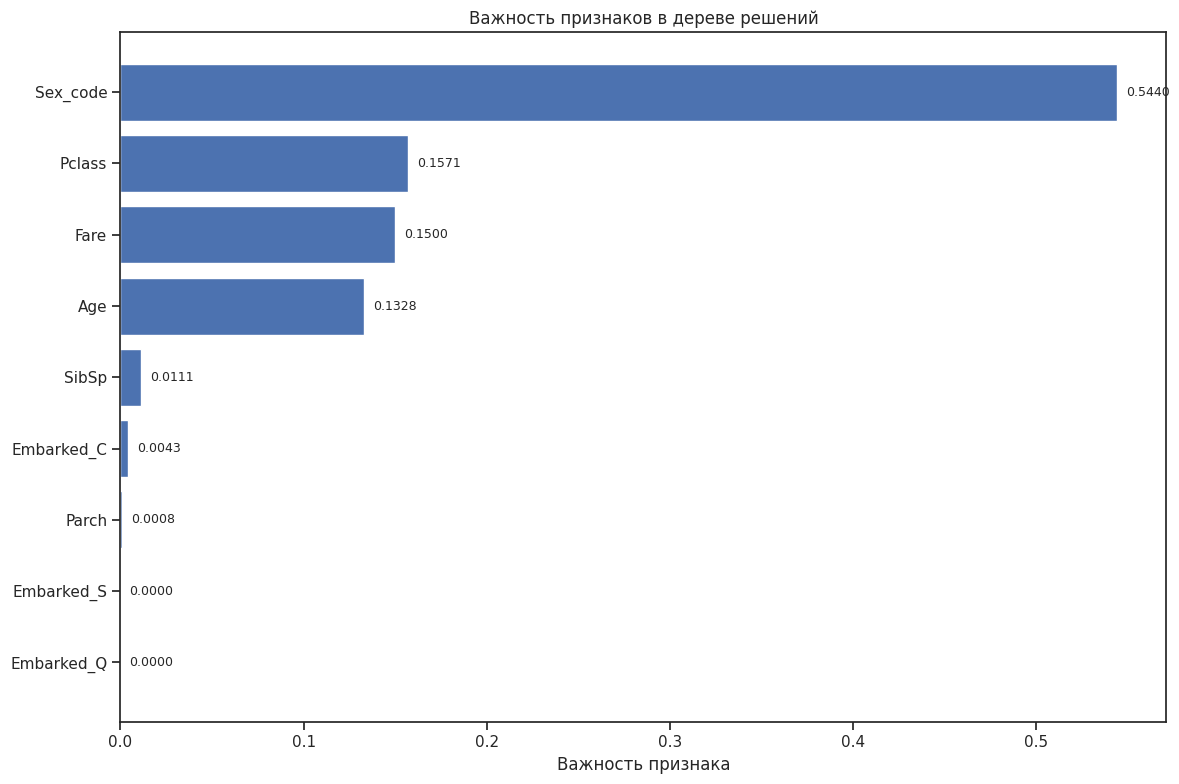

In [26]:
# @title 13. Важность признаков в дереве решений
# Получаем важность признаков
feature_importance = dt_model.feature_importances_

# Сортируем по убыванию
sorted_idx = np.argsort(feature_importance)[::-1]

print("\nРанжирование признаков по важности:")
for i, idx in enumerate(sorted_idx):
    print(f"  {i+1}. {feature_cols[idx]}: {feature_importance[idx]:.4f}")

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(feature_importance)), feature_importance[sorted_idx])
plt.yticks(range(len(feature_importance)), [feature_cols[i] for i in sorted_idx])
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений')
plt.gca().invert_yaxis()

# Добавляем значения на столбцы
for bar, val in zip(bars, feature_importance[sorted_idx]):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()


ПРАВИЛА ДЕРЕВА РЕШЕНИЙ (текстовое представление):
------------------------------------------------------------
|--- Sex_code <= -0.31
|   |--- Pclass <= 0.23
|   |   |--- Fare <= -0.07
|   |   |   |--- Fare <= -0.08
|   |   |   |   |--- Age <= 2.05
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Age >  2.05
|   |   |   |   |   |--- class: 0
|   |   |   |--- Fare >  -0.08
|   |   |   |   |--- class: 0
|   |   |--- Fare >  -0.07
|   |   |   |--- Parch <= 1.39
|   |   |   |   |--- class: 1
|   |   |   |--- Parch >  1.39
|   |   |   |   |--- Fare <= 2.09
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Fare >  2.09
|   |   |   |   |   |--- class: 1
|   |--- Pclass >  0.23
|   |   |--- Fare <= -0.49
|   |   |   |--- Age <= -0.01
|   |   |   |   |--- Fare <= -0.51
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Fare >  -0.51
|   |   |   |   |   |--- class: 1
|   |   |   |--- Age >  -0.01
|   |   |   |   |--- class: 0
|   |   |--- Fare >  -0.49
|   |   |   |--- Age <= -1.

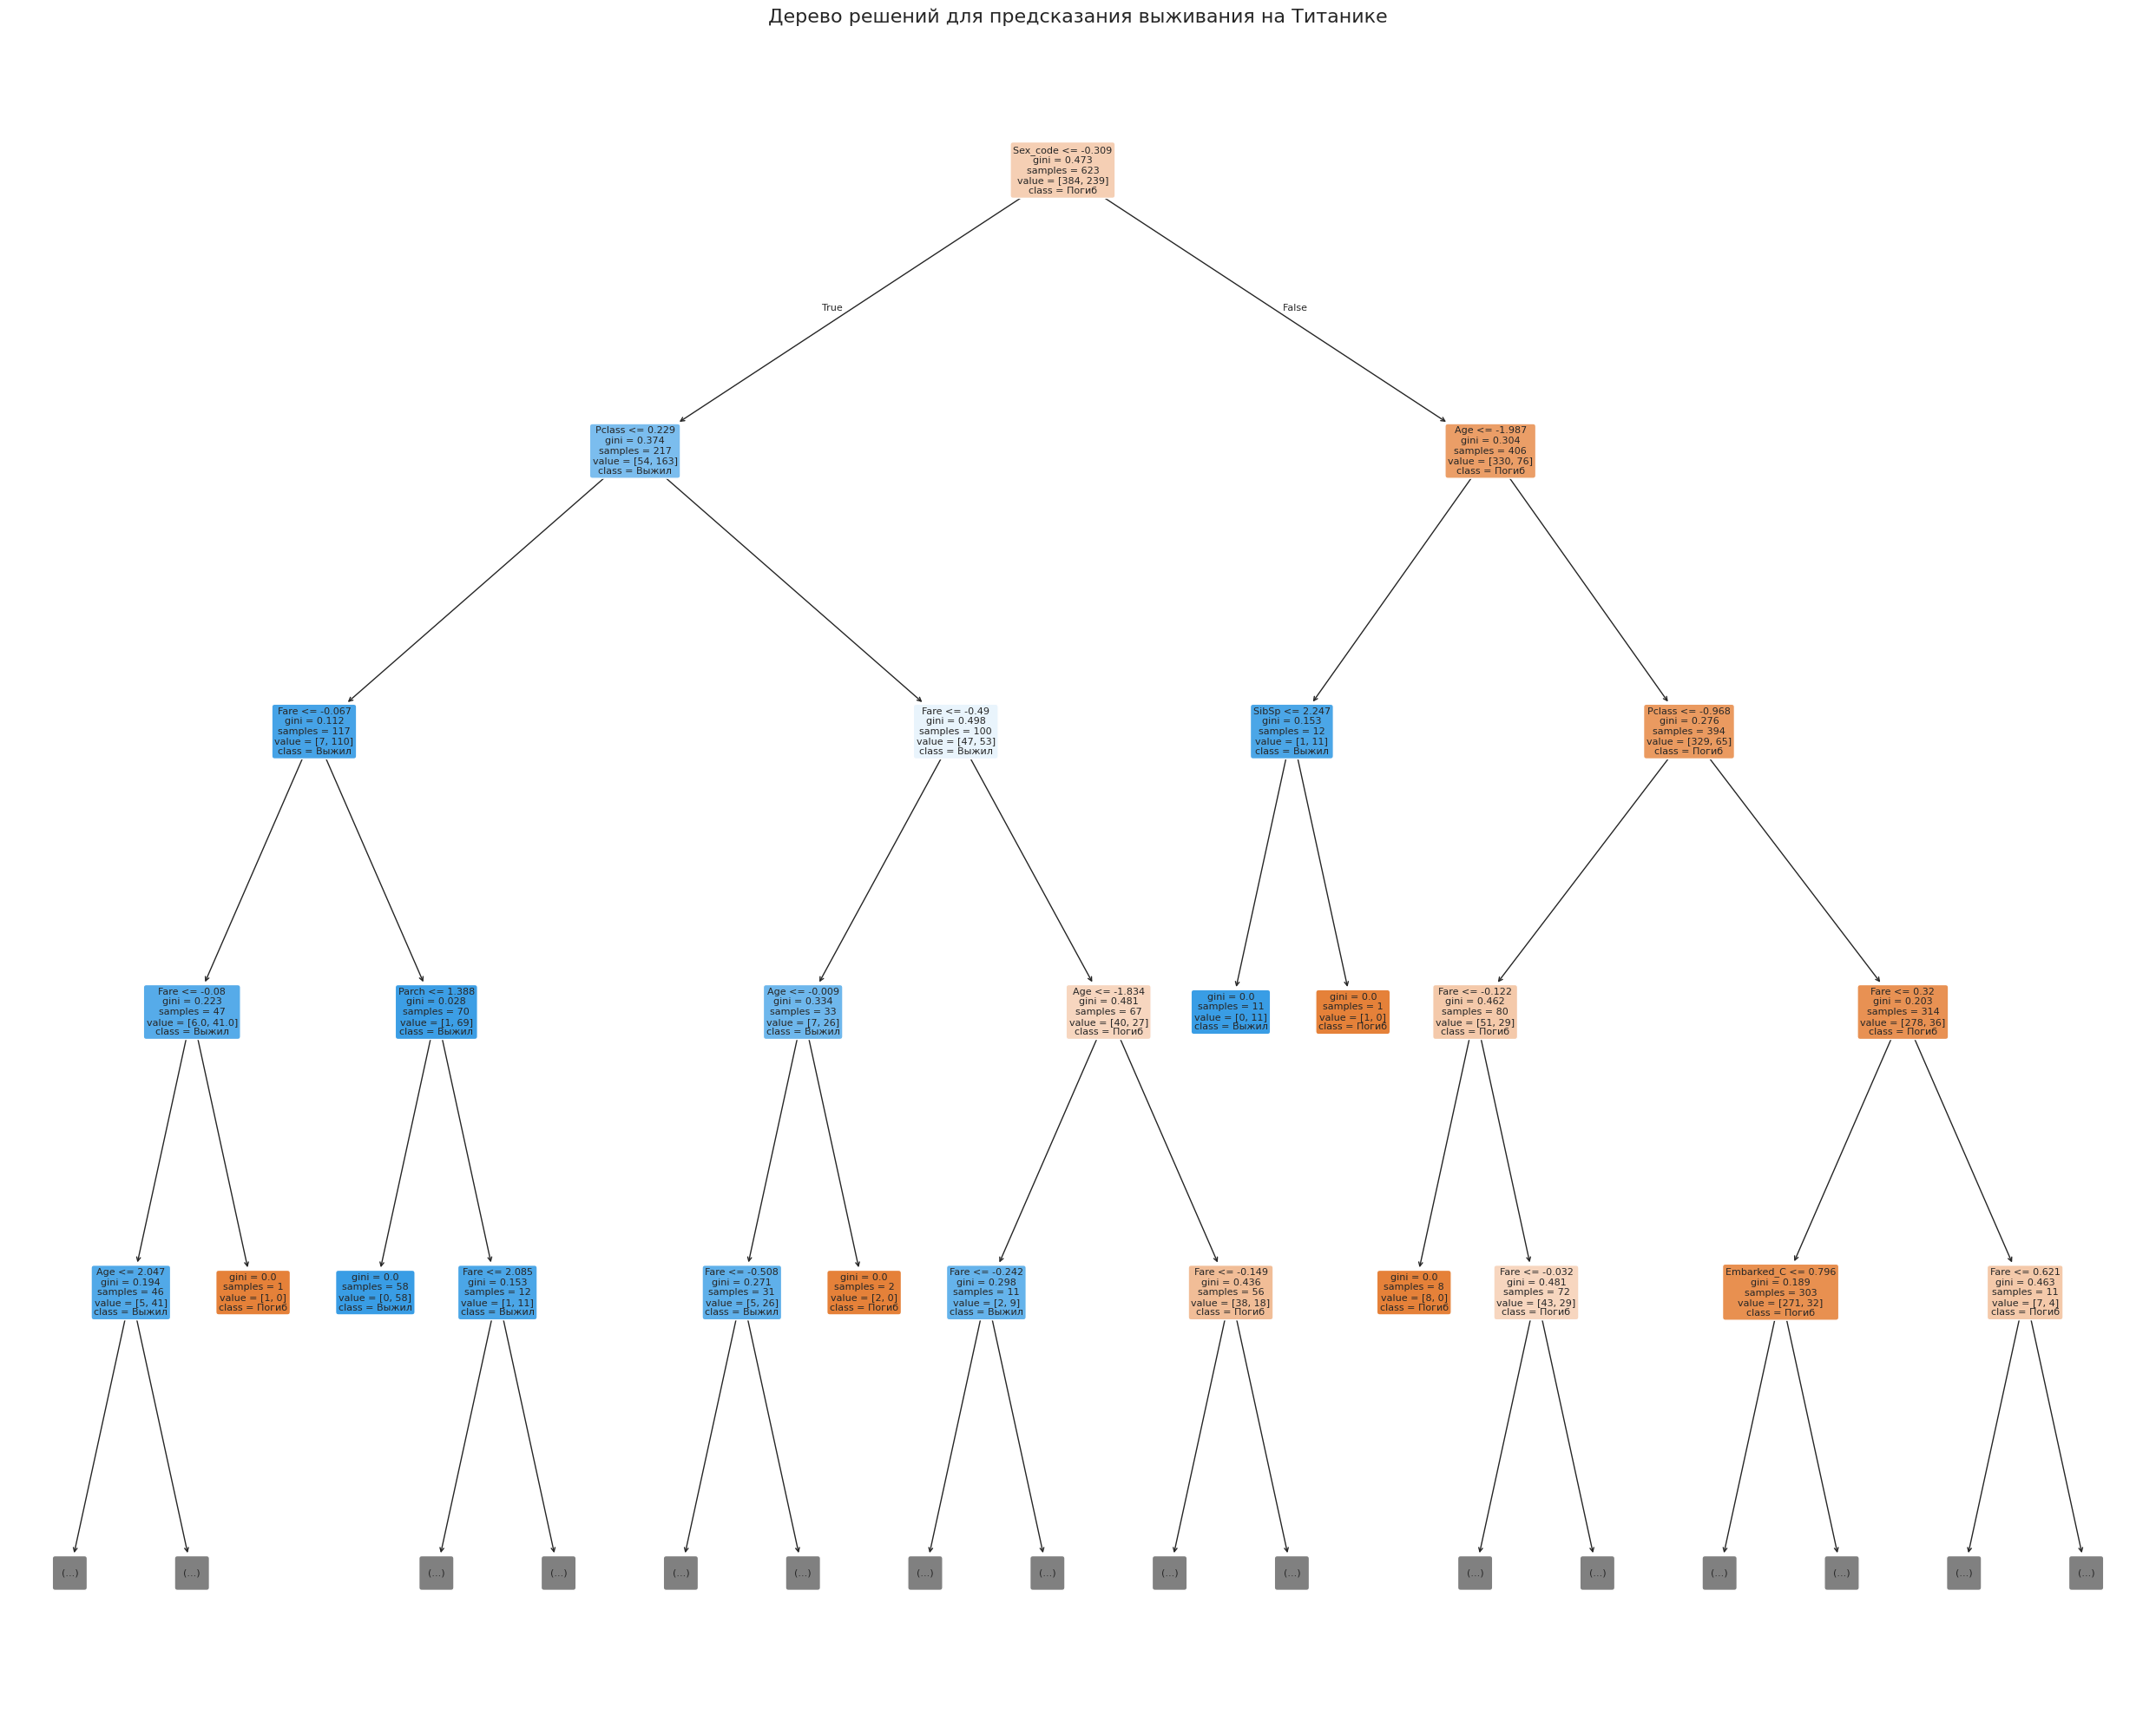

In [27]:
# @title 14. Визуализация дерева решений

# Вывод правил дерева в текстовом виде
print("\nПРАВИЛА ДЕРЕВА РЕШЕНИЙ (текстовое представление):")
print("-"*60)
tree_rules = export_text(dt_model, feature_names=feature_cols, max_depth=4)
print(tree_rules)

# Визуализация дерева
plt.figure(figsize=(25, 20))
plot_tree(dt_model, feature_names=feature_cols, class_names=['Погиб', 'Выжил'],
          filled=True, rounded=True, fontsize=8, max_depth=4)
plt.title('Дерево решений для предсказания выживания на Титанике', fontsize=16)
plt.tight_layout()
plt.show()

In [30]:
# @title 15. Анализ и выводы
# Находим лучшую модель по каждой метрике
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']:
    best_idx = results_df[metric].argmax()
    best_model = results_df.iloc[best_idx]['Модель']
    best_value = results_df.iloc[best_idx][metric]
    print(f"  Лучшая по {metric}: {best_model} ({best_value:.4f})")


  Лучшая по Accuracy: SVM (0.8097)
  Лучшая по Precision: Decision Tree (0.8026)
  Лучшая по Recall: Logistic Regression (0.7282)
  Лучшая по F1-score: Logistic Regression (0.7353)
  Лучшая по ROC-AUC: Logistic Regression (0.8486)


  ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ:

     • Лучший ROC-AUC (0.8486) - отлично разделяет классы
     • Лучший Recall (0.7282) - хорошо находит выживших
     • Лучший F1-score (0.7353) - хороший баланс точности и полноты
     • Вывод: Наиболее сбалансированная модель для данной задачи

  SVM:

     • Лучшая точность (Accuracy: 0.8097) - чаще всего правильно предсказывает
     • Хороший ROC-AUC (0.8466) - близок к лидеру
     • Вывод: Лучшая модель для максимизации общего качества

  ДЕРЕВО РЕШЕНИЙ:

     • Лучшая точность предсказания положительного класса (Precision: 0.8026)
     • Минимальный Recall (0.6364) - пропускает много выживших
     • Вывод: Хорошо для подтверждения выживания, но может пропускать случаи
    
  • Наиболее важными признаками для предсказания выживания являются:
  
    - Пол (Sex) - женщины выживали чаще
    - Класс билета (Pclass) - пассажиры первого класса имели преимущество
    - Возраст (Age) - дети имели приоритет при эвакуации
    - Стоимость билета (Fare) - коррелирует с классом обслуживания